In [ ]:
!pip install torchviz
!pip install torchsummary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 108.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 109.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvji

In [ ]:
!pip install onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 113.2 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
from glob import glob
import random


In [ ]:
# prompt: mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# prompt: add gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
mode ="Retrain"# "Train" # "Retrain", "Adapt"

In [ ]:
current_model_name = 'ResNet_3D_mod_1'
model_path = '/content/drive/MyDrive/Projects/AR_CAM/Models'

In [ ]:
# ------------------------------------------
# 1. Hyperparameters & Configuration
# ------------------------------------------
DATASET_DIR = "/content/drive/MyDrive/Projects/AR_CAM/dataset2/synthetic"
RESOLUTION = 128
BATCH_SIZE = 32
EPOCHS = 20 #50
LEARNING_RATE = 1e-2
ADAPT_LR = 1e-4
NUM_WORKERS = 4
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.1
TEST_SPLIT = 0.2
SEED = 42
PIN_MEMORY = True  # recommended for GPU training
torch.manual_seed(SEED)
random.seed(SEED)

In [ ]:
PIN_MEMORY = True  # recommended for GPU training

In [ ]:
# ------------------------------------------
# 2. Dataset Class
# ------------------------------------------
import random
import torch

class RandomCubeOrientation:
    """Randomly rotates a 3D tensor into one of 6 cube orientations."""
    def __init__(self, num_orientations=3):
        assert 1 <= num_orientations <= 6, "Must choose between 1 to 6 orientations"
        self.num_orientations = num_orientations

        # Define 6 canonical 3D cube orientations (rotations/flips)
        self.transforms = [
            lambda x: x,  # identity
            lambda x: torch.rot90(x, k=1, dims=[2, 3]),  # rotate around Z
            lambda x: torch.rot90(x, k=2, dims=[2, 3]),
            lambda x: torch.rot90(x, k=1, dims=[1, 3]),  # rotate around Y
            lambda x: torch.rot90(x, k=2, dims=[1, 3]),
            lambda x: torch.rot90(x, k=1, dims=[1, 2])   # rotate around X
        ]

    # def __call__(self, x):
    #     transforms = random.sample(self.transforms, self.num_orientations)
    #     augmented_versions = [t(x.clone()) for t in transforms]
    #     return augmented_versions
    def __call__(self, x):
        t = random.choice(self.transforms)
        return t(x)


# class VoxelDataset(Dataset):
#     def __init__(self, data_files, label_map):
#         self.files = data_files
#         self.label_map = label_map

#     def __len__(self):
#         return len(self.files)

#     def __getitem__(self, idx):
#         path = self.files[idx]
#         voxel = np.load(path).astype(np.float32)
#         voxel = voxel[np.newaxis, :, :, :]  # shape = [1, D, H, W]
#         class_name = os.path.basename(os.path.dirname(path))
#         label = self.label_map[class_name]
#         return torch.tensor(voxel), torch.tensor(label)

class VoxelDataset(torch.utils.data.Dataset):
    def __init__(self, data_paths, label_map, transform=None):
        self.data_paths = data_paths
        self.label_map = label_map
        self.transform = transform

    def __len__(self):
        return len(self.data_paths)

    def __getitem__(self, idx):
        path = self.data_paths[idx]
        voxel = torch.from_numpy(np.load(path)).float().unsqueeze(0)  # [1, D, H, W]

        # extraction from parent folder
        class_name = os.path.basename(os.path.dirname(path))
        label = self.label_map[class_name]

        if self.transform:
            voxel = self.transform(voxel)
        return voxel, torch.tensor(label, dtype=torch.long)




In [ ]:

# ------------------------------------------
# 3. Data Preparation
# ------------------------------------------
# Get all files and build label map
class_folders = [f for f in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, f))]
label_map = {name: idx for idx, name in enumerate(sorted(class_folders))}
all_files = []

for cls in class_folders:
    files = glob(os.path.join(DATASET_DIR, cls, '*.npy'))
    print(len(files))
    all_files.extend(files)

random.shuffle(all_files)
total = len(all_files)
train_len = int(total * TRAIN_SPLIT)
val_len = int(total * VAL_SPLIT)
test_len = int(total * TEST_SPLIT)
# Calculate remaining safely
leftover = total - (train_len + val_len + test_len)

# dataset = VoxelDataset(all_files, label_map)


1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000


In [ ]:


if leftover > 0:
    train_files = all_files[:train_len]
    val_files = all_files[train_len:train_len + val_len]
    test_files = all_files[train_len + val_len:train_len + val_len + test_len]
    print("Leftover files not used:", leftover)
else:
    train_files = all_files[:train_len]
    val_files = all_files[train_len:train_len + val_len]
    test_files = all_files[train_len + val_len:]

# Step 2: Define transform (only for training set)
augment_transform = RandomCubeOrientation(num_orientations= 2 )

# Step 3: Create datasets with appropriate transforms
train_dataset = VoxelDataset(train_files, label_map, transform=augment_transform)
val_dataset   = VoxelDataset(val_files, label_map)
test_dataset  = VoxelDataset(test_files, label_map)

# Step 4: Wrap into dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS , pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS , pin_memory=PIN_MEMORY)


In [ ]:
num_samples = len(train_loader.dataset)
print("Number of training samples:", num_samples)


Number of training samples: 16800


In [ ]:
len(train_loader)

525

In [ ]:
len(all_files)

24000

### Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PreActBlock3D(nn.Module):
    """Pre-activation version of BasicBlock with LeakyReLU"""
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.bn1 = nn.BatchNorm3d(in_channels)
        self.conv1 = nn.Conv3d(in_channels, out_channels,
                              kernel_size=3, stride=stride,
                              padding=1, bias=False)
        self.bn2 = nn.BatchNorm3d(out_channels)
        self.conv2 = nn.Conv3d(out_channels, out_channels,
                              kernel_size=3, stride=1,
                              padding=1, bias=False)
        self.leaky_relu = nn.LeakyReLU(0.1, inplace=True)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv3d(in_channels, out_channels,
                         kernel_size=1, stride=stride,
                         bias=False)
            )

    def forward(self, x):
        # Pre-activation
        out = self.leaky_relu(self.bn1(x))
        shortcut = self.shortcut(out) if isinstance(self.shortcut, nn.Sequential) else x
        out = self.conv1(out)

        out = self.leaky_relu(self.bn2(out))
        out = self.conv2(out)

        return out + shortcut

class ResNet3D(nn.Module):
    def __init__(self, block, num_blocks, num_classes=24, initial_channels=64):
        super().__init__()
        self.in_channels = initial_channels

        # Initial layers
        self.init_conv = nn.Conv3d(1, initial_channels,
                                  kernel_size=7, stride=2,
                                  padding=3, bias=False)
        self.init_pool = nn.MaxPool3d(kernel_size=3, stride=2, padding=1)

        # Residual stages
        self.stage1 = self._make_stage(block, 64, num_blocks[0], stride=1)
        self.stage2 = self._make_stage(block, 128, num_blocks[1], stride=2)
        self.stage3 = self._make_stage(block, 256, num_blocks[2], stride=2)
        self.stage4 = self._make_stage(block, 512, num_blocks[3], stride=2)
        self.stage5 = self._make_stage(block, 512, num_blocks[4], stride=1)

        # Final layers with residual connection
        self.global_pool = nn.AdaptiveAvgPool3d((1, 1, 1))
        self.fc1 = nn.Linear(512, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)
        self.fc_shortcut = nn.Linear(512, num_classes)  # Residual for classifier

        # Initialize weights
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='leaky_relu')
            elif isinstance(m, nn.BatchNorm3d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.constant_(m.bias, 0)

    def _make_stage(self, block, channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks - 1)
        blocks = []
        for stride in strides:
            blocks.append(block(self.in_channels, channels, stride))
            self.in_channels = channels
        return nn.Sequential(*blocks)

    def forward(self, x):
        # Initial processing
        x = self.init_conv(x)
        x = self.init_pool(x)

        # Residual stages
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.stage5(x)

        # Classification with residual
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)

        # Main branch
        fc_out = self.fc1(x)
        fc_out = F.leaky_relu(fc_out, 0.1)
        fc_out = self.dropout(fc_out)
        fc_out = self.fc2(fc_out)

        # Shortcut branch
        shortcut = self.fc_shortcut(x)

        return fc_out + shortcut  # Residual connection
# ResNet26_3D_PREACT_ResidualMLP
def ResNet26_3D_PREACT_ResidualMLP(num_classes=24):
    """Custom 23-layer 3D ResNet with pre-activation blocks"""
    return ResNet3D(PreActBlock3D, [2, 2, 2, 2, 2], num_classes)

In [ ]:
# ------------------------------------------
# 5. Training & Evaluation Utilities
# ------------------------------------------
# def train(model, loader, optimizer, criterion, device):
#     model.train()
#     total_loss = 0
#     for x, y in loader:
#         x, y = x.to(device), y.to(device)
#         optimizer.zero_grad()
#         out = model(x)
#         loss = criterion(out, y)
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()
#     return total_loss / len(loader)

def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy



def evaluate(model, loader, device):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            _, pred = torch.max(out, 1)
            preds.extend(pred.cpu().numpy())
            labels.extend(y.numpy())
    return preds, labels


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)

            total_loss += loss.item() * x.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    avg_loss = total_loss / total
    accuracy = 100 * correct / total
    return avg_loss, accuracy



In [ ]:
# ------------------------------------------
# 6. Run Training
# ------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 📂 Path for loading/saving
full_model_path = os.path.join(model_path, f"{current_model_name}.pth")

# -----------------------------
# A. Train
# -----------------------------
model = ResNet26_3D_PREACT_ResidualMLP(num_classes=len(label_map)).to(device)
if mode == "Train":
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()

# -----------------------------
# B. Retrain (load weights first)
# -----------------------------
elif mode == "Retrain":
    print(f"♻️ Retraining: loading model from {full_model_path}")
    model.load_state_dict(torch.load(full_model_path, map_location=device))
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()


# -----------------------------
# C. Adapt to new domain (fine-tune)
# -----------------------------
elif mode == "Adapt":
    print(f"🌍 Domain Adaptation: loading pretrained model from {full_model_path}")
    model.load_state_dict(torch.load(full_model_path, map_location=device))

    # Freeze all but final layers (e.g., last stage + classifier)
    for name, param in model.named_parameters():
        if "stage5" in name or "fc" in name or "classifier" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False

    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=ADAPT_LR)
    criterion = nn.CrossEntropyLoss()

else:
    raise ValueError(f" Unknown mode: {mode}")


♻️ Retraining: loading model from /content/drive/MyDrive/Projects/AR_CAM/Models/ResNet_3D_mod_1.pth


In [ ]:

# mode = "Train"  # Choose from: "Train", "Retrain", "Adapt"
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Define model
# model = ResNet26_3D_PREACT_ResidualMLP(num_classes=len(label_map)).to(device)

# # 📂 Path for loading/saving
# full_model_path = os.path.join(model_path, f"{current_model_name}.pth")



# # -----------------------------
# # 2. Retrain (load weights first)
# # -----------------------------
# elif mode == "Retrain":
#     print(f"♻️ Retraining: loading model from {full_model_path}")
#     model.load_state_dict(torch.load(full_model_path, map_location=device))
#     optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
#     criterion = nn.CrossEntropyLoss()

# # -----------------------------
# # 3. Adapt to new domain (fine-tune)
# # -----------------------------
# elif mode == "Adapt":
#     print(f"🌍 Domain Adaptation: loading pretrained model from {full_model_path}")
#     model.load_state_dict(torch.load(full_model_path, map_location=device))

#     # Freeze all but final layers (e.g., last stage + classifier)
#     for name, param in model.named_parameters():
#         if "stage5" in name or "fc" in name or "classifier" in name:
#             param.requires_grad = True
#         else:
#             param.requires_grad = False

#     optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=ADAPT_LR)
#     criterion = nn.CrossEntropyLoss()

# else:
#     raise ValueError(f"❌ Unknown mode: {mode}")


In [ ]:
import time

In [ ]:
EPOCHS = 10

In [ ]:
start_time = time.time()

# your code block here
# for epoch in range(EPOCHS):
#     loss = train(model, train_loader, optimizer, criterion, device)
#     print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {loss:.4f}")
# history = {
#     'train_loss': [],
#     'train_acc': [],
#     'val_loss': [],
#     'val_acc': []
# }

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    # Save to history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")



end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.2f} seconds")


Epoch 1/10 | Train Loss: 3.2208 | Train Acc: 4.58% | Val Loss: 3.2236 | Val Acc: 4.33%


KeyboardInterrupt: 

In [ ]:
# prompt: add accuracy use import the accuracy
from sklearn.metrics import accuracy_score

# ------------------------------------------
# 7. Final Evaluation
# ------------------------------------------
preds, labels = evaluate(model, test_loader, device)



In [ ]:
# Calculate accuracy
accuracy = accuracy_score(labels, preds)
print(f"\nTest Accuracy: {accuracy:.4f}")

print("\nClassification Report:\n", classification_report(labels, preds, target_names=label_map.keys()))
# print("Confusion Matrix:\n", confusion_matrix(labels, preds))


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Confusion matrix (formatted)
cm = confusion_matrix(labels, preds)
cm_df = pd.DataFrame(cm, index=label_map.keys(), columns=label_map.keys())

# 3. Display as heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=.5, linecolor='gray')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Save Model

In [ ]:
# ------------------------------------------
# 8. Save the trained model
# ------------------------------------------
full_model_path = os.path.join(model_path, f"{current_model_name}.pth")
torch.save(model.state_dict(), full_model_path)
print(f"Model saved to {full_model_path}")

In [ ]:
import json

# Define the path to save the label map
label_map_path = os.path.join(model_path, f"{current_model_name}_label_map.json")

# Save the label map to a JSON file
with open(label_map_path, 'w') as f:
    json.dump(label_map, f)

print(f"Label map saved to {label_map_path}")

In [ ]:
# ## For Future Use
# # Instantiate your model
# # Make sure the model architecture (FeatureNet3D in this case) is the same as the saved model
# loaded_model = FeatureNet3D(num_classes=len(label_map)).to(device)

# # Load the saved state dictionary
# loaded_model.load_state_dict(torch.load(full_model_path))

# # Set the model to evaluation mode
# loaded_model.eval()

# print(f"Model loaded successfully from {full_model_path}")

In [ ]:
# Get one batch from your DataLoader
sample_batch = next(iter(train_loader))

# Unpack it: voxel, label
sample_input, _ = sample_batch

# Move to device (e.g., CUDA)
sample_input = sample_input.to(device)

torch.onnx.export(
    model,
    sample_input,                      # Use actual input
    "resnet3d.onnx",
    opset_version=11,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)
print("Model exported to resnet3d.onnx using actual sample input.")


In [ ]:
from torchviz import make_dot

model = ResNet26_3D_PREACT_ResidualMLP(num_classes=24).to(device)

y = model(sample_input)

make_dot(y, params=dict(model.named_parameters())).render("resnet3d_graph", format="png")


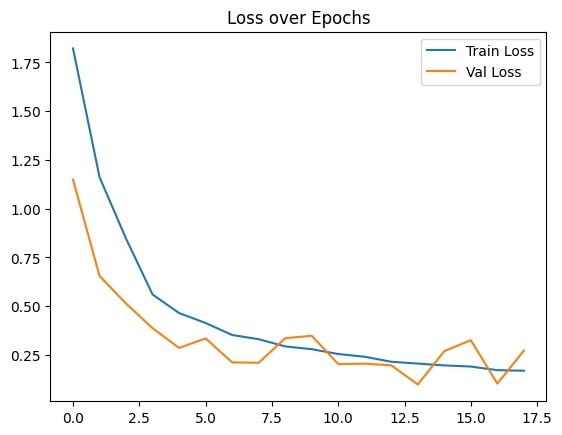

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss over Epochs")
plt.show()




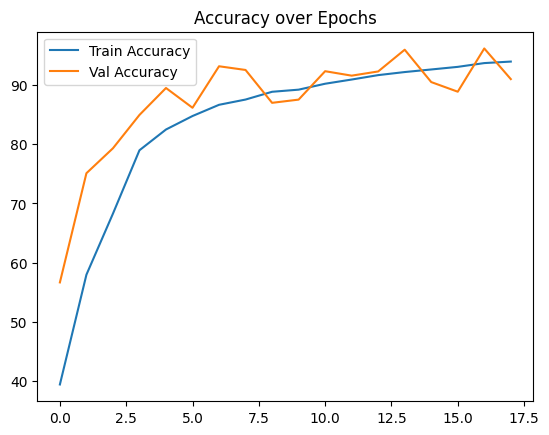

In [ ]:
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy over Epochs")
plt.show()

In [ ]:
import os

# Convert history dictionary to DataFrame
df_history = pd.DataFrame(history)

# Construct full path
csv_filename = f"{current_model_name}_training_history.csv"
csv_path = os.path.join(model_path, csv_filename)

# Save the file
df_history.to_csv(csv_path, index=False)
print(f"✅ Training history saved to {csv_path}")


✅ Training history saved to /content/drive/MyDrive/Projects/AR_CAM/Models/ResNet_3D_mod_1_training_history.csv
